✅ Dataset Loaded Successfully!
Shape: (7043, 21)
✅ Data Cleaning Done!

📊 Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


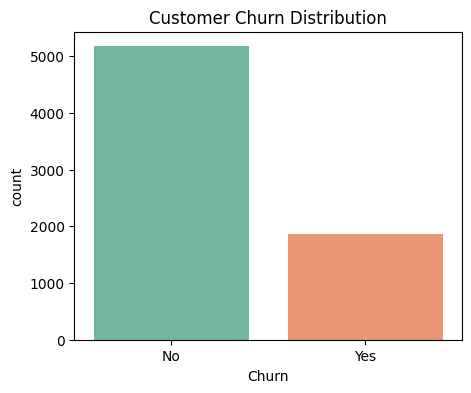

✅ Encoding Done!
✅ Data Split Done!
Training Samples: 5634
Testing Samples: 1409
✅ Feature Scaling Done!
✅ Model Training Completed!

🎯 Accuracy: 78.71%

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



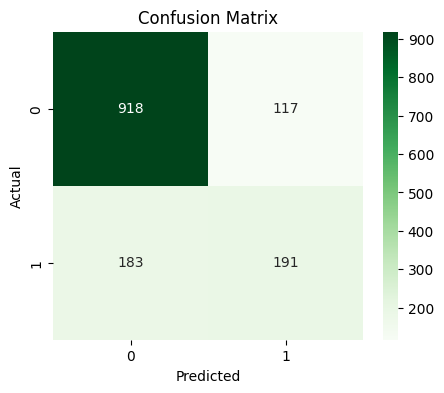

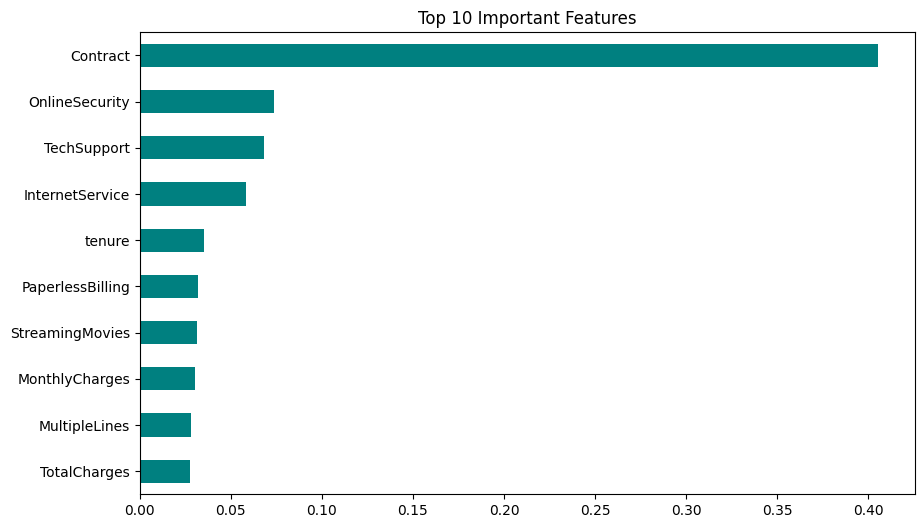

✅ Feature Importance Analyzed!
💾 Model & Scaler Saved Successfully!

🚀 Telco Customer Churn Prediction Project Completed Successfully!


In [ ]:
# ============================================================
# 📘 TELCO CUSTOMER CHURN PREDICTION (Full Project)
# ============================================================
# By: Muhammad Rayan Shahid | ByteBrilliance AI
# ============================================================

# STEP 1: Install dependencies
!pip install scikit-learn matplotlib seaborn xgboost --quiet

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import zipfile

# ============================================================
# STEP 3: Extract dataset
# ============================================================
# ⚠️ Make sure 'archive.zip' is uploaded in Colab (left sidebar > Files)
# e.g., /content/archive.zip

with zipfile.ZipFile("/content/archive.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

# After extraction, the CSV file will be available in /content/
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("✅ Dataset Loaded Successfully!")
print("Shape:", df.shape)
df.head()

# ============================================================
# STEP 4: Data Cleaning
# ============================================================

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Replace spaces in string values
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Replace empty strings in 'TotalCharges' and convert to numeric
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Drop customerID (not useful for prediction)
df.drop("customerID", axis=1, inplace=True)

print("✅ Data Cleaning Done!")

# ============================================================
# STEP 5: Exploratory Data Analysis (Quick Insights)
# ============================================================

print("\n📊 Churn Distribution:")
print(df["Churn"].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Customer Churn Distribution")
plt.show()

# ============================================================
# STEP 6: Encode Categorical Columns
# ============================================================

# Encode target variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Identify categorical columns
cat_cols = df.select_dtypes(include="object").columns

# Apply Label Encoding
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Encoding Done!")

# ============================================================
# STEP 7: Train-Test Split
# ============================================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Data Split Done!")
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# ============================================================
# STEP 8: Feature Scaling
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature Scaling Done!")

# ============================================================
# STEP 9: Model Training (XGBoost)
# ============================================================

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train_scaled, y_train)
print("✅ Model Training Completed!")

# ============================================================
# STEP 10: Evaluation
# ============================================================

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f"\n🎯 Accuracy: {acc*100:.2f}%")
print("\nClassification Report:\n", cr)

# Confusion Matrix Visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# STEP 11: Feature Importance
# ============================================================

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='barh', color='teal')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

print("✅ Feature Importance Analyzed!")

# ============================================================
# STEP 12: Save the Model
# ============================================================

import joblib
joblib.dump(model, "telco_churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("💾 Model & Scaler Saved Successfully!")

# ============================================================
# PROJECT COMPLETE ✅
# ============================================================

print("\n🚀 Telco Customer Churn Prediction Project Completed Successfully!")
